<a href="https://colab.research.google.com/github/MuhammadAhmed196/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadAhmed196/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The current action queue uses the validated Week-4 baseline because it outperformed the Week-5 Random Forest on the held-out client evaluation. The baseline prioritizes pages that are both stale and visible: at least 180 days since the last update and at least 500 impressions in the last 90 days.

Ranked actions:
- refresh_review — stale and visible pages. These are the primary candidates for human refresh review.
- monitor — pages that do not meet both baseline conditions and therefore are not prioritized by this rule.

Reason codes:
- stale_visible — the page is at least 180 days since update and has at least 500 impressions in the last 90 days.
- stale_low_visibility — the page is stale but has fewer than 500 impressions.
- fresh_visible — the page has at least 500 impressions but is not yet stale.
- other — the page satisfies neither stronger condition.

Archetype-to-action mapping:
- Stale + visible → refresh_review
- Stale + low visibility → monitor
- Fresh + visible → monitor
- Other → monitor

The queue is decision-support, not an automatic instruction to change content. A human reviewer should confirm the recommendation before any refresh work is started.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import subprocess
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Load the same starter data used by the Week-4 baseline
# ---------------------------------------------------------

REPO_DIR = "flyrank-ml-internship-starter"
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"

if not os.path.isdir(REPO_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
        check=True
    )

data_path = os.path.join(
    REPO_DIR,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

df = pd.read_csv(data_path)

# ---------------------------------------------------------
# Build the validated Week-4 baseline queue
# ---------------------------------------------------------

stale = (
    df["days_since_last_update"] >= 180
)

visible = (
    df["impressions_90d"] >= 500
)

df["baseline_action_score"] = (
    stale.astype(int)
    * visible.astype(int)
    * df["impressions_90d"]
)

df["reason_code"] = np.select(
    [
        stale & visible,
        stale & ~visible,
        ~stale & visible
    ],
    [
        "stale_visible",
        "stale_low_visibility",
        "fresh_visible"
    ],
    default="other"
)

df["action_label"] = np.where(
    df["reason_code"] == "stale_visible",
    "refresh_review",
    "monitor"
)

df["baseline_rank"] = (
    df["baseline_action_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

ranked_queue = (
    df[
        [
            "content_id",
            "client_id",
            "baseline_rank",
            "baseline_action_score",
            "reason_code",
            "action_label",
            "impressions_90d",
            "days_since_last_update",
            "avg_position",
            "ctr"
        ]
    ]
    .sort_values("baseline_rank")
    .reset_index(drop=True)
)

print("Ranked queue rows:", len(ranked_queue))
print("\nAction counts:")
display(
    ranked_queue["action_label"]
    .value_counts()
    .rename_axis("action_label")
    .to_frame("row_count")
)

print("\nReason-code counts:")
display(
    ranked_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .to_frame("row_count")
)

print("\nTop 10 ranked actions:")
display(ranked_queue.head(10))


Ranked queue rows: 30000

Action counts:


,row_count
action_label,
monitor,29983
refresh_review,17



Reason-code counts:


,row_count
reason_code,
fresh_visible,16709
other,13117
stale_low_visibility,157
stale_visible,17



Top 10 ranked actions:


,content_id,client_id,baseline_rank,baseline_action_score,reason_code,action_label,impressions_90d,days_since_last_update,avg_position,ctr
0,content_cf56e2e2e282,client_7f2253d7e2,1,61678,stale_visible,refresh_review,61678,194,19.7,0.15
1,content_7368877ea310,client_7f2253d7e2,2,59472,stale_visible,refresh_review,59472,194,24.8,0.13
2,content_1bfaa38ff26c,client_7f2253d7e2,3,25715,stale_visible,refresh_review,25715,194,22.2,0.23
3,content_0a91db491d14,client_7f2253d7e2,4,13299,stale_visible,refresh_review,13299,193,10.5,0.49
4,content_5feee3994adb,client_7f2253d7e2,5,7812,stale_visible,refresh_review,7812,194,39.0,0.01
5,content_c2d929d83eaa,client_7f2253d7e2,6,7558,stale_visible,refresh_review,7558,193,17.9,0.20
6,content_b16bd7307b39,client_7f2253d7e2,7,4590,stale_visible,refresh_review,4590,194,31.0,0.00
7,content_fe16a55cd13d,client_7f2253d7e2,8,4556,stale_visible,refresh_review,4556,194,16.4,0.33
8,content_ecb6215e79fd,client_7f2253d7e2,9,4429,stale_visible,refresh_review,4429,194,25.3,0.38
9,content_928af3e22c80,client_7f2253d7e2,10,1697,stale_visible,refresh_review,1697,193,15.8,0.12


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use:
The ranked queue is intended for editors or content teams who need a small, prioritized set of pages to review for possible refresh work. The score is a decision-support ranking, not a prediction that a page must be refreshed. The current queue is based on the validated Week-4 baseline because it outperformed the Week-5 Random Forest on the held-out client evaluation.

Limits:
The rule only uses recent visibility and staleness. It does not account for business importance, search intent changes, content quality, seasonality, recent technical changes, or other editorial context. The rule also produced only 17 refresh_review recommendations in this dataset, so it should not be interpreted as covering every page that may need attention. Recommendations should be rechecked against current page context before action.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---------------------------------------------------------
# INTENDED USE + LIMIT CHECK
# ---------------------------------------------------------

refresh_count = (
    ranked_queue["action_label"]
    .eq("refresh_review")
    .sum()
)

monitor_count = (
    ranked_queue["action_label"]
    .eq("monitor")
    .sum()
)

refresh_share = refresh_count / len(ranked_queue)

print("Pages ranked for refresh review:", refresh_count)
print("Pages left for monitoring:", monitor_count)
print("Refresh-review share:", round(refresh_share, 4))

print("\nCurrent intended use: human-reviewed prioritization")
print("Automatic publishing/editing: NO")
print("Automatic refresh decision: NO")


Pages ranked for refresh review: 17
Pages left for monitoring: 29983
Refresh-review share: 0.0006

Current intended use: human-reviewed prioritization
Automatic publishing/editing: NO
Automatic refresh decision: NO


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review rules:
Before acting on a refresh_review recommendation, an editor should confirm that the page is still published, the observed search visibility is current, the page intent is still relevant, and there is a clear content or maintenance reason to consider an update. The reviewer should also check for recent changes that may not yet be reflected in the available data.

No-go cases:
The recommendation should not be acted on automatically when the page has a major technical problem, is intentionally seasonal or time-sensitive, is part of a protected or sensitive content set, has recently been updated but the update is not reflected in the data, or when the evidence is too weak to justify changing the page. The system must not automatically publish, rewrite, delete, redirect, or change a page.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---------------------------------------------------------
# HUMAN REVIEW + NO-GO CHECK
# ---------------------------------------------------------

review_rules = pd.DataFrame({
    "check": [
        "Page is still published",
        "Search visibility is current",
        "Page intent is still relevant",
        "There is a clear reason to consider a refresh",
        "No very recent unrecorded update is suspected"
    ],
    "required_before_action": [True, True, True, True, True]
})

no_go_cases = pd.DataFrame({
    "no_go_case": [
        "Major technical issue",
        "Intentional seasonal or time-sensitive page",
        "Protected or sensitive content",
        "Recent update not yet reflected in the data",
        "Insufficient evidence for a content change"
    ],
    "automatic_action": ["NO"] * 5
})

print("Human-review checks:")
display(review_rules)

print("\nNo-go cases:")
display(no_go_cases)

print("\nAutomatic publishing/rewrite/delete/redirect: NO")


Human-review checks:


,check,required_before_action
0,Page is still published,True
1,Search visibility is current,True
2,Page intent is still relevant,True
3,There is a clear reason to consider a refresh,True
4,No very recent unrecorded update is suspected,True



No-go cases:


,no_go_case,automatic_action
0,Major technical issue,NO
1,Intentional seasonal or time-sensitive page,NO
2,Protected or sensitive content,NO
3,Recent update not yet reflected in the data,NO
4,Insufficient evidence for a content change,NO



Automatic publishing/rewrite/delete/redirect: NO


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring and retrain triggers:

The recommendation system should be rechecked when the underlying data or its meaning changes materially. A new evaluation should be triggered if Precision@50 on a later labelled window falls meaningfully below the current validated benchmark, if the distribution of key inputs such as impressions or days_since_last_update changes substantially, or if data availability changes enough to alter which pages can enter the queue. Retraining or rule revision should also be considered if the target definition changes, the available features change, or editorial review shows repeated systematic errors.

The system should not be continuously retrained without a reason. A new version should be evaluated against the existing baseline under the same validation design before it replaces the current approach.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---------------------------------------------------------
# MONITORING / RETRAIN TRIGGERS
# ---------------------------------------------------------

monitoring_triggers = pd.DataFrame({
    "trigger": [
        "Precision@50 drops materially on a later labelled evaluation window",
        "Key feature distributions change materially",
        "Data availability changes materially",
        "Target definition changes",
        "Available features or data source changes",
        "Human review finds repeated systematic recommendation errors"
    ],
    "response": [
        "Re-evaluate the baseline/model",
        "Run a distribution and data-quality audit",
        "Review filtering and feature availability",
        "Rebuild and revalidate the target",
        "Rebuild and revalidate the feature pipeline",
        "Investigate errors and consider rule/model revision"
    ]
})

print("Monitoring / retrain triggers:")
display(monitoring_triggers)

print(
    "\nReplacement rule: a revised system must beat or justify "
    "replacement of the current baseline under the same validation design."
)


Monitoring / retrain triggers:


,trigger,response
0,Precision@50 drops materially on a later label...,Re-evaluate the baseline/model
1,Key feature distributions change materially,Run a distribution and data-quality audit
2,Data availability changes materially,Review filtering and feature availability
3,Target definition changes,Rebuild and revalidate the target
4,Available features or data source changes,Rebuild and revalidate the feature pipeline
5,Human review finds repeated systematic recomme...,Investigate errors and consider rule/model rev...



Replacement rule: a revised system must beat or justify replacement of the current baseline under the same validation design.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked action queue is exported for reuse in the final research paper. The queue contains the page identifier, rank, score, action label, and reason code needed to reproduce the recommendations. The queue remains a generated output rather than a committed data file. Reusable figures are stored under work/figures/ and metric receipts can be stored as JSON under work/outputs/.

Ranked queue exported to:
flyrank-ml-internship-starter/work/outputs/baseline_action_score.csv

Metrics receipt exported to:
flyrank-ml-internship-starter/work/outputs/week07_metrics.json


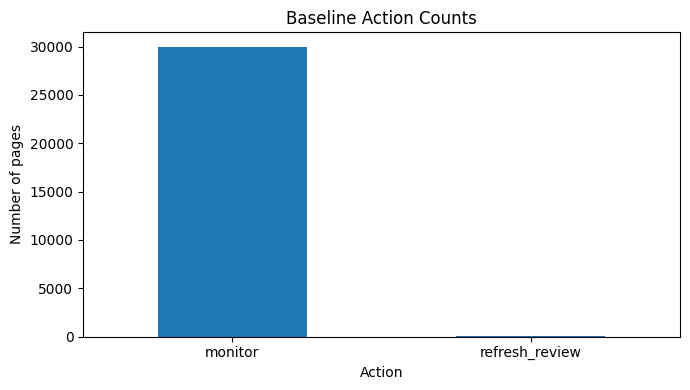


Figure saved to:
flyrank-ml-internship-starter/work/figures/baseline_action_counts.png


In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---------------------------------------------------------
# EXPORTS FOR THE PAPER
# ---------------------------------------------------------

from pathlib import Path
import json

# Output directories
outputs_dir = Path(REPO_DIR) / "work" / "outputs"
figures_dir = Path(REPO_DIR) / "work" / "figures"

outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Export the ranked queue
# ---------------------------------------------------------

queue_path = outputs_dir / "baseline_action_score.csv"

ranked_queue.to_csv(
    queue_path,
    index=False
)

print("Ranked queue exported to:")
print(queue_path)

# ---------------------------------------------------------
# 2. Save metric receipt
# ---------------------------------------------------------

metrics = {
    "lane": "Content Refresh Prioritization",
    "baseline": "Week-4 stale-and-visible rule",
    "baseline_precision_at_50": 0.620,
    "week5_random_forest_precision_at_50": 0.560,
    "validation_design": "client-grouped holdout",
    "refresh_review_count": int(
        ranked_queue["action_label"]
        .eq("refresh_review")
        .sum()
    ),
    "total_rows": int(len(ranked_queue))
}

metrics_path = outputs_dir / "week07_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("\nMetrics receipt exported to:")
print(metrics_path)

# ---------------------------------------------------------
# 3. Create a simple reusable figure
# ---------------------------------------------------------

import matplotlib.pyplot as plt

action_counts = (
    ranked_queue["action_label"]
    .value_counts()
)

plt.figure(figsize=(7, 4))
action_counts.plot(kind="bar")
plt.title("Baseline Action Counts")
plt.xlabel("Action")
plt.ylabel("Number of pages")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = figures_dir / "baseline_action_counts.png"

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(figure_path)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.